In [203]:
#####################################################################################################################
### The code is used to conduct statistical comparison between 2 sets of data via A12 statistic for LINE COVERAGE ###
#####################################################################################################################

In [204]:
import pandas as pd
import pingouin as pg
from typing import Dict
import matplotlib.pyplot as plt
from common import (
    filter_out_failed_iterations,
    filter_out_projects_within_list,

    calculate_pvalue_and_A12,
    build_comparison_boxplot,
    prettify_prompt_name,
    count_iterations_with_compilable_test_cases,
    threshold_projects_on_compilable_iterations,
)

In [205]:
# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Convert DataFrame to a string with no truncation
pd.set_option('display.max_colwidth', None)

In [206]:
#########################################################
### Filepaths to the generated CSV data               ###
### Required columns for the datasets' CSV file:      ###
###    1. build_id,                                   ###
###    2. cut_quialified_name,                        ###
###    3. iteration,                                  ###
###    4. prompt_id,                                  ###
###    4. lines_covered,                              ###
###    5. lines_total,                                ###
###    6. branches_covered,                           ###
###    7. branches_total,                             ###
###    8. compilable_test_cases,                      ###
###    9. total_test_cases                            ###
#########################################################

#### input CSV data filepaths & output CSV data filepaths ####

csv_filename = "results.csv" # "testspark-coverage-results.csv"
output_coverage_filename = "testspark_line_coverage.csv" # "line_coverage.csv"
output_mean_coverage_filename = "testspark_mean_line_coverage.csv" # "mean_line_coverage.csv"



#### NOTES ####
# 1. RQ1 = "CUT"
# 1. RQ2 = "METHODS_DECLARATION"
# 1. config-1 = config-I = "5 iterations"
# 2. config-2 = config-II = "1 iteration"

#### RQ1:
### GPT-4 ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-II/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/GPT-4/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"

### Llama-3.1-70B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-I/TestSpark/{csv_filename}"
dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-II/TestSpark/{csv_filename}"
model = "Llama-3.1-70B-Instruct"
prompt_id_A = "CUT-5"
prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.1-8B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.2-3B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.2-1B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2 | NOTE: ERROR: NO OBJECTS TO CONCATENATE
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2 | NOTE: ERROR: NO OBJECTS TO CONCATENATE
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"



#### RQ2:
### GPT-4 ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.1-70B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.1-8B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.2-3B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.2-1B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"




# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# prompt_id_A = "gpt4-RQ2"
# prompt_id_B = "llama70b-RQ2"

line_coverage_merged_output_filepath = \
    f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/{output_coverage_filename}"
line_coverage_mean_merged_output_filepath = \
    f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/{output_mean_coverage_filename}"


save_output_in_csv = False
REMOVE_PAIRED_RESULTS_WITH_ZERO_LINE_COVERAGE = True
# minimal number of iterations with at least 1 compilable test case
MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES = 10

In [207]:
#########################################################################
### Block with function implementations used afterwards in the script ###
#########################################################################


def collect_line_coverage(data, remove_unsuccessful_coverage=False):
    """
    Collects the line coverage from the dataset.

    1. 'data' - the pandas data frame.
    2. 'remove_unsuccessful_coverage': if true then removes the rows that have zeros in their 'lines_total' column.
    """
    if remove_unsuccessful_coverage:
        # filter out zero total lines (i.e. those where coverage could not be collected)
        data = data[data['lines_total'] > 0]

    line_coverage = pd.DataFrame(data[['build_id', 'iteration', 'prompt_id', 'lines_covered', 'lines_total']])

    lines_total_gt_zero = line_coverage[line_coverage['lines_total'] > 0]
    line_coverage['line_coverage'] = line_coverage['lines_covered'] / lines_total_gt_zero['lines_total']
    line_coverage['line_coverage'] = line_coverage['line_coverage'].fillna(0.0)

    return line_coverage


def merge_line_coverage(A, prompt_id_A: str, B, prompt_id_B: str, ignore_index=False):
    line_coverage_projects = []

    # TODO: add comments of how it works
    for build_id, projectA in A.groupby('build_id'):
        projectA = projectA[projectA['lines_total'] > 0]
        projectA = projectA.reset_index().drop(columns=['index'])

        if build_id not in B.groupby('build_id').groups:
            print(f"WARNING: '{build_id}' not found in the second dataset. Skipping '{build_id}'...", flush=True)
            continue

        projectB = B.groupby('build_id').get_group(build_id)
        projectB = projectB[projectB['lines_total'] > 0]
        projectB = projectB.reset_index().drop(columns=['index'])

        merged_line_coverage_data = pd.merge(
            projectA, # x
            projectB, # y
            left_index=True,
            right_index=True,
            how='inner'
        )
        line_coverage_projects.append(merged_line_coverage_data)

    line_coverage_merged = pd.concat(line_coverage_projects, ignore_index=ignore_index)
    line_coverage_merged = line_coverage_merged \
        .rename(columns={
            'build_id_x': 'build_id',

            'iteration_x': f'iteration_{prompt_id_A}',
            'line_coverage_x': f'line_coverage_{prompt_id_A}',

            'iteration_y': f'iteration_{prompt_id_B}',
            'line_coverage_y': f'line_coverage_{prompt_id_B}',
        }) \
        .drop(columns=[
            'prompt_id_x',
            'lines_covered_x',
            'lines_total_x',

            'build_id_y',
            'prompt_id_y',
            'lines_covered_y',
            'lines_total_y',
        ])
    return line_coverage_merged


In [208]:
################################
### Read results of prompt A ###
################################

data_A = pd.read_csv(dataset_A)
# filter iterations listed in the notes of context length overflow
# data_A = filter_out_failed_iterations(data_A, notes_filepath_A)
data_A.head()

,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1


In [209]:
#############################################################################
# Remain projects with at least N iterations with >=1 compilable test cases #
#############################################################################

data_A = threshold_projects_on_compilable_iterations(data_A, n=MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES)
data_A.head()

Iterations Count Shape: (13, 2)


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama70b-RQ1-CUT-5-iter,6,9,0,0,2,2,1


In [210]:
#############################################################
# Count the number of iterations for the remaining projects #
#############################################################

iterations_count_A = count_iterations_with_compilable_test_cases(data_A)
iterations_count_A

Iterations Count Shape: (13, 2)


,build_id,iteration_count
0,ConfigMe-7449db4901,15
1,ConfigMe-cab40d1c3c,15
2,formatter-maven-plugin-a6994326aa,15
3,java-solutions-7a73ea56d0,15
4,jsoup-2f48a617fe,15
5,jsoup-5afef3ecc0,15
6,jsoup-9d104b7ea2,15
7,jsoup-c507588b5c,15
8,jsoup-e1880ad73e,15
9,jsoup-f0eb6bd1cc,15


In [211]:
################################
### Form line coverage for A ###
################################

line_coverage_A = collect_line_coverage(data_A)
# line_coverage_A = line_coverage_A[line_coverage_A['build_id'] == 'epubcheck-49aacb238c'].reset_index().drop(columns=['index'])
# line_coverage_A = line_coverage_A.drop(index=[1,4,5,7])
line_coverage_A.head()

,build_id,iteration,prompt_id,lines_covered,lines_total,line_coverage
0,ConfigMe-7449db4901,0,llama70b-RQ1-CUT-5-iter,6,9,0.666667
1,ConfigMe-7449db4901,1,llama70b-RQ1-CUT-5-iter,6,9,0.666667
2,ConfigMe-7449db4901,2,llama70b-RQ1-CUT-5-iter,6,9,0.666667
3,ConfigMe-7449db4901,3,llama70b-RQ1-CUT-5-iter,6,9,0.666667
4,ConfigMe-7449db4901,4,llama70b-RQ1-CUT-5-iter,6,9,0.666667


In [212]:
################################
### Read results of prompt B ###
################################

data_B = pd.read_csv(dataset_B)
# filter iterations listed in the notes of context length overflow
# data_B = filter_out_failed_iterations(data_B, notes_filepath_B)
data_B.head()

,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1


In [213]:
#############################################################################
# Remain projects with at least N iterations with >=1 compilable test cases #
#############################################################################

data_B = threshold_projects_on_compilable_iterations(data_B, n=MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES)
data_B.head()

Iterations Count Shape: (13, 2)


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama70b-RQ1-CUT-1-iter,6,9,0,0,2,2,1


In [214]:
#############################################################
# Count the number of iterations for the remaining projects #
#############################################################

iterations_count_B = count_iterations_with_compilable_test_cases(data_B)
iterations_count_B

Iterations Count Shape: (13, 2)


,build_id,iteration_count
0,ConfigMe-7449db4901,15
1,ConfigMe-cab40d1c3c,15
2,formatter-maven-plugin-a6994326aa,15
3,java-solutions-7a73ea56d0,15
4,jsoup-2f48a617fe,15
5,jsoup-5afef3ecc0,15
6,jsoup-9d104b7ea2,15
7,jsoup-c507588b5c,15
8,jsoup-e1880ad73e,15
9,jsoup-f0eb6bd1cc,15


In [215]:
################################
### Form line coverage for B ###
################################

line_coverage_B = collect_line_coverage(data_B)
# line_coverage_B = line_coverage_B[line_coverage_B['build_id'] == 'epubcheck-49aacb238c'].reset_index().drop(columns=['index'])
# line_coverage_B = line_coverage_B.drop(index=[31,32,39,12])
line_coverage_B.head()

,build_id,iteration,prompt_id,lines_covered,lines_total,line_coverage
0,ConfigMe-7449db4901,0,llama70b-RQ1-CUT-1-iter,6,9,0.666667
1,ConfigMe-7449db4901,1,llama70b-RQ1-CUT-1-iter,6,9,0.666667
2,ConfigMe-7449db4901,2,llama70b-RQ1-CUT-1-iter,6,9,0.666667
3,ConfigMe-7449db4901,3,llama70b-RQ1-CUT-1-iter,6,9,0.666667
4,ConfigMe-7449db4901,4,llama70b-RQ1-CUT-1-iter,6,9,0.666667


In [216]:
#################################
### Merge CSV result datasets ###
#################################
line_coverage_merged = merge_line_coverage(line_coverage_A, prompt_id_A, line_coverage_B, prompt_id_B)
# remove 3rd row of 'epubcheck-49aacb238c' project: [3	epubcheck-49aacb238c	0.032698	0.000000]
# line_coverage_merged = line_coverage_merged.reset_index().drop(columns=['index'])
# line_coverage_merged = line_coverage_merged.drop(index=3)
# line_coverage_merged = line_coverage_merged[line_coverage_merged["build_id"] == "jsoup-195f484ba5"].drop(index=2)
line_coverage_merged.head()

,build_id,iteration_CUT-5,line_coverage_CUT-5,iteration_CUT-1,line_coverage_CUT-1
0,ConfigMe-7449db4901,0,0.666667,0,0.666667
1,ConfigMe-7449db4901,1,0.666667,1,0.666667
2,ConfigMe-7449db4901,2,0.666667,2,0.666667
3,ConfigMe-7449db4901,3,0.666667,3,0.666667
4,ConfigMe-7449db4901,4,0.666667,4,0.666667


In [217]:
######################################################################
### Count the number of successful attempts of coverage collection ###
######################################################################

successful_line_coverage_collections_per_project = line_coverage_merged.reset_index()\
        .groupby('build_id')\
        .agg({ 'index': 'count' })\
        .rename(columns={ 'index': 'successful_line_coverage_collections_count' })

print(f"===== {prompt_id_A} \ {prompt_id_B} =====")
successful_line_coverage_collections_per_project

===== CUT-5 \ CUT-1 =====


,successful_line_coverage_collections_count
build_id,
ConfigMe-7449db4901,15
ConfigMe-cab40d1c3c,15
formatter-maven-plugin-a6994326aa,15
java-solutions-7a73ea56d0,15
jsoup-2f48a617fe,15
jsoup-5afef3ecc0,15
jsoup-9d104b7ea2,15
jsoup-c507588b5c,15
jsoup-e1880ad73e,15


In [218]:
#######################################################################
# Remove projects that do not have all the required prompt components #
#######################################################################

# NOTE: list 'projects_with_methods_info_only' for augmented prompt and polymorphism-only prompt
# projects_with_methods_info_only = ['frigga-126b52a558', 'jsoup-195f484ba5']
# projects_to_remove = []

# if prompt_id_A != 'methods_only_prompt':
#     projects_to_remove = projects_with_methods_info_only

# print(f"Prompts: {prompt_id_A} / {prompt_id_B}")
# print(f"Projects to remove: {projects_to_remove}")

# line_coverage_merged = filter_out_projects_within_list(line_coverage_merged, projects_to_remove)

In [219]:
##############################################################
### Save merged line coverage of both datasets into a file ###
##############################################################

if save_output_in_csv:
    line_coverage_merged.to_csv(line_coverage_merged_output_filepath)

In [220]:

# TODO: temporary remove one project for llama-8B:
# line_coverage_merged = line_coverage_merged[line_coverage_merged['build_id'] != 'java-solutions-7a73ea56d0']

In [221]:
##################################################################################
### Create and save the mean merged line coverage of both datasets into a file ###
##################################################################################

line_coverage_mean_merged = line_coverage_merged.groupby('build_id').agg({
    f'line_coverage_{prompt_id_A}': 'mean',
    f'line_coverage_{prompt_id_B}': 'mean',
})
line_coverage_mean_merged

,line_coverage_CUT-5,line_coverage_CUT-1
build_id,,
ConfigMe-7449db4901,0.666667,0.666667
ConfigMe-cab40d1c3c,0.800000,0.878788
formatter-maven-plugin-a6994326aa,0.111111,0.111111
java-solutions-7a73ea56d0,0.956522,0.956522
jsoup-2f48a617fe,0.937500,0.937500
jsoup-5afef3ecc0,0.675000,0.661667
jsoup-9d104b7ea2,0.780000,0.780000
jsoup-c507588b5c,0.800000,0.800000
jsoup-e1880ad73e,0.673913,0.673913


In [222]:
##################################################################################
### 1) Collect p-value of the line coverage results present in both datasets   ###
###                                                                            ###
### A, B - groups                                                              ###
### p_value(A, B)                                                              ###
###   1. p > 0.05 - not significant                                            ###
###   2. p < 0.05 -> (significance) look to effect size (\in 0..1)             ###
### ef = effect_size(A, B)                                                     ###
###   1. ef -> 0: A wins (bigger ef -> bigger difference)                      ###
###   2. ef -> 0.5: no differnce                                               ###
###   3. ef -> 1: B wins                                                       ###
###                                                                            ###
### 2) Calculate A12 measure for the line coverage of both datasets by project ###
###                                                                            ###
### 3) Install A12 values to the merged mean line coverage of both datasets    ###
##################################################################################

calculate_pvalue_and_A12(line_coverage_merged, line_coverage_mean_merged, prompt_id_A, prompt_id_B, 'line_coverage')
line_coverage_mean_merged

ConfigMe-7449db4901: pvalue=1.0, A12=0.5
ConfigMe-cab40d1c3c: pvalue=0.032261460853811146, A12=0.36666666666666664
formatter-maven-plugin-a6994326aa: pvalue=1.0, A12=0.5
java-solutions-7a73ea56d0: pvalue=1.0, A12=0.5
jsoup-2f48a617fe: pvalue=nan, A12=0.5
jsoup-5afef3ecc0: pvalue=0.1533573322784189, A12=0.5666666666666667
jsoup-9d104b7ea2: pvalue=1.0, A12=0.5
jsoup-c507588b5c: pvalue=1.0, A12=0.5
jsoup-e1880ad73e: pvalue=1.0, A12=0.5
jsoup-f0eb6bd1cc: pvalue=1.0, A12=0.5
nfe-ec5ddf7e73: pvalue=nan, A12=0.5
solarpositioning-2756287e64: pvalue=nan, A12=0.5
solarpositioning-8faa18c702: pvalue=nan, A12=0.5


/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/ubuntu/research-work-2024/test-generation-research/scripts/analysis/common.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "pvalue": t_test_line_coverage_result['p-val'][0],
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples

,line_coverage_CUT-5,line_coverage_CUT-1,pvalue,A12
build_id,,,,
ConfigMe-7449db4901,0.666667,0.666667,1.000000,0.500000
ConfigMe-cab40d1c3c,0.800000,0.878788,0.032261,0.366667
formatter-maven-plugin-a6994326aa,0.111111,0.111111,1.000000,0.500000
java-solutions-7a73ea56d0,0.956522,0.956522,1.000000,0.500000
jsoup-2f48a617fe,0.937500,0.937500,NaN,0.500000
jsoup-5afef3ecc0,0.675000,0.661667,0.153357,0.566667
jsoup-9d104b7ea2,0.780000,0.780000,1.000000,0.500000
jsoup-c507588b5c,0.800000,0.800000,1.000000,0.500000
jsoup-e1880ad73e,0.673913,0.673913,1.000000,0.500000


In [223]:
#########################################################################
### Remove projects that have 0 line coverage for both configurations ###
#########################################################################

if REMOVE_PAIRED_RESULTS_WITH_ZERO_LINE_COVERAGE:
    print(f"Number of projects for both configurations: {len(line_coverage_mean_merged)}")

    projects_with_coverage_A_mask = line_coverage_mean_merged[f'line_coverage_{prompt_id_A}'] > 0
    projects_with_coverage_B_mask = line_coverage_mean_merged[f'line_coverage_{prompt_id_B}'] > 0

    line_coverage_mean_merged = line_coverage_mean_merged[projects_with_coverage_A_mask & projects_with_coverage_B_mask]

    print(f"Number of projects with line coverage > 0 for both configurations: {len(line_coverage_mean_merged)}")

line_coverage_mean_merged

Number of projects for both configurations: 13
Number of projects with line coverage > 0 for both configurations: 13


,line_coverage_CUT-5,line_coverage_CUT-1,pvalue,A12
build_id,,,,
ConfigMe-7449db4901,0.666667,0.666667,1.000000,0.500000
ConfigMe-cab40d1c3c,0.800000,0.878788,0.032261,0.366667
formatter-maven-plugin-a6994326aa,0.111111,0.111111,1.000000,0.500000
java-solutions-7a73ea56d0,0.956522,0.956522,1.000000,0.500000
jsoup-2f48a617fe,0.937500,0.937500,NaN,0.500000
jsoup-5afef3ecc0,0.675000,0.661667,0.153357,0.566667
jsoup-9d104b7ea2,0.780000,0.780000,1.000000,0.500000
jsoup-c507588b5c,0.800000,0.800000,1.000000,0.500000
jsoup-e1880ad73e,0.673913,0.673913,1.000000,0.500000


In [224]:
########################################################
### Save merged mean line coveraged of both datasets ###
########################################################

if save_output_in_csv:
    line_coverage_mean_merged.to_csv(line_coverage_mean_merged_output_filepath)
    print(f"Data successfully saved into '{line_coverage_mean_merged_output_filepath}'")
else:
    print(f"No data saving requested")

No data saving requested


Projects: 13
Unsupported prompt id: 'CUT-5'
Unsupported prompt id: 'CUT-1'
Unsupported prompt id: 'CUT-5'
Unsupported prompt id: 'CUT-1'
Unsupported prompt id: 'CUT-5'
Unsupported prompt id: 'CUT-1'


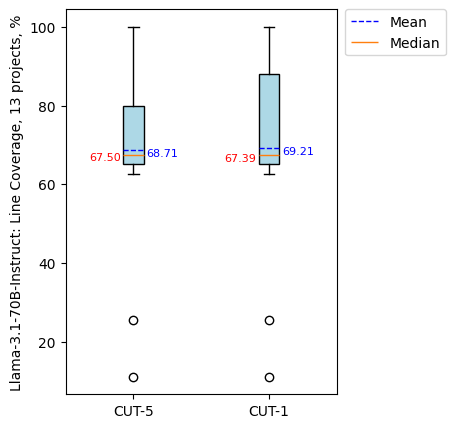

In [225]:
#######################################################
# Draw boxplots for the line coverage of both prompts #
#######################################################

# line_coverage_merged
# line_coverage_mean_merged

projects_cnt = line_coverage_mean_merged.shape[0]
print(f"Projects: {projects_cnt}")

prompt_A_name = prettify_prompt_name(prompt_id_A)
prompt_B_name = prettify_prompt_name(prompt_id_B)

bp = build_comparison_boxplot(
    dataset_A=round(100 * line_coverage_mean_merged[[f'line_coverage_{prompt_id_A}']], 2).to_numpy().flatten().tolist(),
    dataset_B=round(100 * line_coverage_mean_merged[[f'line_coverage_{prompt_id_B}']], 2).to_numpy().flatten().tolist(),
    prompt_type_A=prompt_id_A,
    prompt_type_B=prompt_id_B,
    ylabel=f'{model}: Line Coverage, {projects_cnt} projects, %',
    # title=f'Line Coverage between {prompt_A_name} and {prompt_B_name} Prompts'
)